# Figure 2

Paper panels with figure-specific PDF and CSV exports. Run from top to bottom. Original analysis notebooks are preserved.

## Setup

In [3]:
from pathlib import Path
from tempfile import TemporaryDirectory
from contextlib import contextmanager
from IPython.display import IFrame, display
from matplotlib.transforms import Bbox
import itertools
import os
import shutil
import pandas as pd
import KinematicPlot as kp
from group_config_new import build_groups
from survival_stats_runner import SurvivalStatsRunner

# All persistent exports belong to this paper figure, with one folder per panel.
ROOT = Path.cwd()
if not (ROOT / "KinematicPlot.py").is_file():
    raise RuntimeError("Run this notebook from the repository root.")
FIGURE_NUMBER = 2
NOTEBOOK_OUTPUT_DIR = ROOT / "Figures" / f"Figure{FIGURE_NUMBER}"
SC_DATA_DIR = ROOT / "SC data"
N_PERM = 20000
plotter = kp.PlotCreator()
stats_runner = SurvivalStatsRunner(tau=0.71, random_state=0, platform_offset=0.03, radius=0.07, fps=250)

def output_folder(*parts):
    # Create output folders only when the notebook is executed.
    folder = NOTEBOOK_OUTPUT_DIR.joinpath(*parts)
    folder.mkdir(parents=True, exist_ok=True)
    return folder

def panel_prefix(panel, name):
    return output_folder(f"Figure{panel}") / f"Figure{panel}_{name}"

def show_pdf(path, width=950, height=700):
    display(IFrame(src=Path(path).relative_to(ROOT).as_posix(), width=width, height=height))

@contextmanager
def working_directory(folder):
    # Preserve the working directory for legacy notebook loader calls.
    previous = Path.cwd()
    os.chdir(folder)
    try:
        yield
    finally:
        os.chdir(previous)

In [4]:
# Shared WT tracking QC thresholds for angle and TT trajectory analyses.
# Change WT_QC_ERROR_MAX here to adjust the reprojection-error cutoff for both.
WT_QC_ERROR_MAX = 30
WT_QC_SCORE_MIN = 0.8
WT_QC_MIN_CAMERAS = 2
WT_QC_MAX_INTERP_GAP_S = 0.02
WT_QC_MAX_INVALID_FRACTION = 0.3
WT_QC_MIN_VALID_FRACTION = 1.0 - WT_QC_MAX_INVALID_FRACTION

# Smooth after QC/interpolation with the utilities exponential moving average.
WT_ANGLE_SMOOTH = True
WT_ANGLE_SMOOTH_ALPHA = 0.4

WT_ANGLE_QC_KWARGS = dict(
    apply_tracking_qc=True,
    min_cameras=WT_QC_MIN_CAMERAS,
    max_interp_gap_s=WT_QC_MAX_INTERP_GAP_S,
    min_valid_fraction=WT_QC_MIN_VALID_FRACTION,
    error_max=WT_QC_ERROR_MAX,
    score_min=WT_QC_SCORE_MIN,
    smooth_angle=WT_ANGLE_SMOOTH,
    smooth_alpha=WT_ANGLE_SMOOTH_ALPHA,
)

WT_TT_QC_KWARGS = dict(
    apply_tracking_qc=True,
    min_cameras=WT_QC_MIN_CAMERAS,
    max_interp_gap_s=WT_QC_MAX_INTERP_GAP_S,
    min_valid_fraction=WT_QC_MIN_VALID_FRACTION,
    error_max=WT_QC_ERROR_MAX,
    score_min=WT_QC_SCORE_MIN,
)

WT_ANGLE_QC_KWARGS, WT_TT_QC_KWARGS

({'apply_tracking_qc': True,
  'min_cameras': 2,
  'max_interp_gap_s': 0.02,
  'min_valid_fraction': 0.7,
  'error_max': 30,
  'score_min': 0.8,
  'smooth_angle': True,
  'smooth_alpha': 0.4},
 {'apply_tracking_qc': True,
  'min_cameras': 2,
  'max_interp_gap_s': 0.02,
  'min_valid_fraction': 0.7,
  'error_max': 30,
  'score_min': 0.8})

In [5]:
def export_generated(prefix, default_panel, name, routes=None, pdfs=None):
    # Copy every generated CSV; route selected files to their actual figure panel.
    # Explicit PDF selection excludes extra figures produced by legacy functions.
    routes = routes or {}
    exported = []
    for source in sorted(prefix.parent.glob(prefix.name + "*")):
        suffix = source.name[len(prefix.name):]
        if source.suffix == ".pdf" and pdfs is not None and suffix not in pdfs:
            continue
        if source.suffix not in (".csv", ".pdf"):
            continue
        panel = routes.get(suffix, default_panel)
        target = Path(str(panel_prefix(panel, name)) + suffix)
        shutil.copy2(source, target)
        exported.append(target)
    return exported

def export_axes(fig, axes, destination):
    # Export existing plotted artists without recalculating data or statistics.
    # Hide other axes so adjacent panels cannot appear in the exported PDF.
    selected = list(axes)
    visibility = {ax: ax.get_visible() for ax in fig.axes}
    text_visibility = {label: label.get_visible() for label in fig.texts}
    try:
        for ax in fig.axes:
            ax.set_visible(ax in selected)
        # Combined-figure titles do not describe an individually exported panel.
        for label in fig.texts:
            label.set_visible(False)
        fig.canvas.draw()
        renderer = fig.canvas.get_renderer()
        bounds = Bbox.union([ax.get_tightbbox(renderer) for ax in selected])
        bounds = bounds.transformed(fig.dpi_scale_trans.inverted()).padded(0.08)
        fig.savefig(destination, bbox_inches=bounds, dpi=300)
    finally:
        for ax, visible in visibility.items():
            ax.set_visible(visible)
        for label, visible in text_visibility.items():
            label.set_visible(visible)

## WT groups and comparison settings

In [7]:
required_group_keys = [
    "WT_T1_TTa", "WT_T1_CTF",
    "WT_T2_TTa", "WT_T2_CTF",
    "WT_T3_TTa", "WT_T3_CTF",
]

groups = build_groups(
    group_keys=required_group_keys,
    skip_missing=False,
    require_kinematics=False,
)

pd.DataFrame([
    {
        "Config_Key": key,
        "Group_Name": group.group_name,
        "Metadata_Loaded": len(group.trial_metadata),
        "Kinematic_Trials_Loaded": len(group.fly_kinematic_data),
    }
    for key, group in groups.items()
])
wt_tita_groups = {
    "T1": groups["WT_T1_TTa"],
    "T2": groups["WT_T2_TTa"],
    "T3": groups["WT_T3_TTa"],
}
wt_cxtr_groups = {
    "T1": groups["WT_T1_CTF"],
    "T2": groups["WT_T2_CTF"],
    "T3": groups["WT_T3_CTF"],
}
wt_tita_sc_paths = {
    "T1": SC_DATA_DIR / "WT-T1-TiTa_LegContact.csv",
    "T2": SC_DATA_DIR / "WT-T2-TiTa_LegContact.csv",
    "T3": SC_DATA_DIR / "WT-T3-TiTa_LegContact.csv",
}
wt_tita_manual_sc_legs = {
    "T1": ("L-f", "L-m", "L-h", "R-m", "R-h"),
    "T2": ("L-f", "L-m", "L-h", "R-f", "R-h"),
    "T3": ("L-f", "L-m", "L-h", "R-f", "R-m"),
}

wt_groups_ordered = [
    groups["WT_T1_TTa"], groups["WT_T1_CTF"],
    groups["WT_T2_TTa"], groups["WT_T2_CTF"],
    groups["WT_T3_TTa"], groups["WT_T3_CTF"],
]
wt_group_colors = {
    "WT-T1-TiTa": "#1f77b4",
    "WT-T1-CxTr": "#8ecae6",
    "WT-T2-TiTa": "#d62728",
    "WT-T2-CxTr": "#ff9896",
    "WT-T3-TiTa": "#2ca02c",
    "WT-T3-CxTr": "#98df8a",
}
wt_group_markers = {group.group_name: "o" for group in wt_groups_ordered}
wt_group_linestyles = {group.group_name: "solid" for group in wt_groups_ordered}

# Planned WT pairwise tests: compare contact groups within each structure,
# plus the TiTa-vs-CxTr exception within matching contact groups.
wt_planned_group_pairs = [
    (groups["WT_T1_TTa"], groups["WT_T2_TTa"]),
    (groups["WT_T1_TTa"], groups["WT_T3_TTa"]),
    (groups["WT_T2_TTa"], groups["WT_T3_TTa"]),
    (groups["WT_T1_CTF"], groups["WT_T2_CTF"]),
    (groups["WT_T1_CTF"], groups["WT_T3_CTF"]),
    (groups["WT_T2_CTF"], groups["WT_T3_CTF"]),
    (groups["WT_T1_TTa"], groups["WT_T1_CTF"]),
    (groups["WT_T2_TTa"], groups["WT_T2_CTF"]),
    (groups["WT_T3_TTa"], groups["WT_T3_CTF"]),
]

## LL-only control and ablation inputs

In [9]:
import plot_landing as pl
import Seaborn_plot as sp
DATA_FOLDER = ROOT / "Metadata"
# Preserve the existing ablation loader's first-three-trial exclusion and threshold.
sp.FilterHighLatency = True
sp.Trial_num = 20
sp.Threshold = True
sp.trial_offset = 3
sp.latency_threshold = 0.71
ablation_specs = [
    ("WT-T2-TTa", DATA_FOLDER / "WT-LP/T2-TiTa" / "T2-TiTa-LL.xlsx", 200, 1, 15),
    ("WT-SL-T2-TTa", DATA_FOLDER / "Necessity" / "T2RightIntact_TTa_All.xlsx", 300, 1, 21),
    ("WT-T3-TTa", DATA_FOLDER / "WT-LP/T3-TiTa" / "T3-TiTa-LL.xlsx", 200, 1, 15),
    ("WT-T3-TTa", DATA_FOLDER / "WT-LP/T3-TiTa" / "T3-TiTa-LL.xlsx", 250, 16, 20),
    ("WT-SL-T3-TTa", DATA_FOLDER / "Necessity" / "T3RightIntact_TTa_All.xlsx", 300, 1, 17),
]

no_contact_specs = [
    ("WT Abdomen", DATA_FOLDER / "CONTROL" / "WT-Abdomen-ALL.xlsx", 250, 1, 11),
    ("WT Ab T3CutOff", DATA_FOLDER / "CONTROL" / "WT-Ab-LegCutOff-ALL.xlsx", 250, 1, 10),
    ("No contact", DATA_FOLDER / "CONTROL" / "IntactFly_Control.xlsx", 300, 1, 10),
]

def load_lp_data(specs):
    # Read legacy LL-only Excel sheets, then merge repeated labels such as the
    # mixed-FPS WT-T3-TTa group into one fly-level LP dataframe for plotting.
    grouped = {}
    group_order = []
    for label, path, fps, first_fly, last_fly in specs:
        if not path.exists():
            raise FileNotFoundError(path)
        lp_data, _ = sp.ReadLandingData(str(path), label, fps, first_fly, last_fly)
        if label not in grouped:
            grouped[label] = []
            group_order.append(label)
        grouped[label].append(lp_data)
    return [pd.concat(grouped[label], ignore_index=True) for label in group_order]

def run_lp_permutation_stats(data_to_plot, file_name, n_perm=N_PERM):
    # Use the current shared stats runner for fly-level landing-probability
    # comparisons while keeping the notebook independent of Group objects.
    comparisons = list(itertools.combinations(data_to_plot, 2))
    stat_rows = []
    for df_a, df_b in comparisons:
        group_a = str(df_a["Group_Name"].iloc[0])
        group_b = str(df_b["Group_Name"].iloc[0])
        stat_df = plotter.stats_runner.unpaired_permutation_test(
            df_a["LandingProb"].to_numpy(dtype=float),
            df_b["LandingProb"].to_numpy(dtype=float),
            group_a=group_a,
            group_b=group_b,
            metric="landing_probability",
            n_perm=n_perm,
            n_fly_a=df_a["Fly#"].nunique(),
            n_fly_b=df_b["Fly#"].nunique(),
            test_name="ablation_landing_probability_unpaired_permutation",
        )
        stat_df["n_pairwise_comparison"] = len(comparisons)
        stat_rows.append(stat_df)
    combined_stats = pd.concat(stat_rows, ignore_index=True) if stat_rows else pd.DataFrame()
    combined_stats.to_csv(f"{file_name}_landing_probability_permutation_stats.csv", index=False)
    return combined_stats

## Figure 2A - WT landing probability

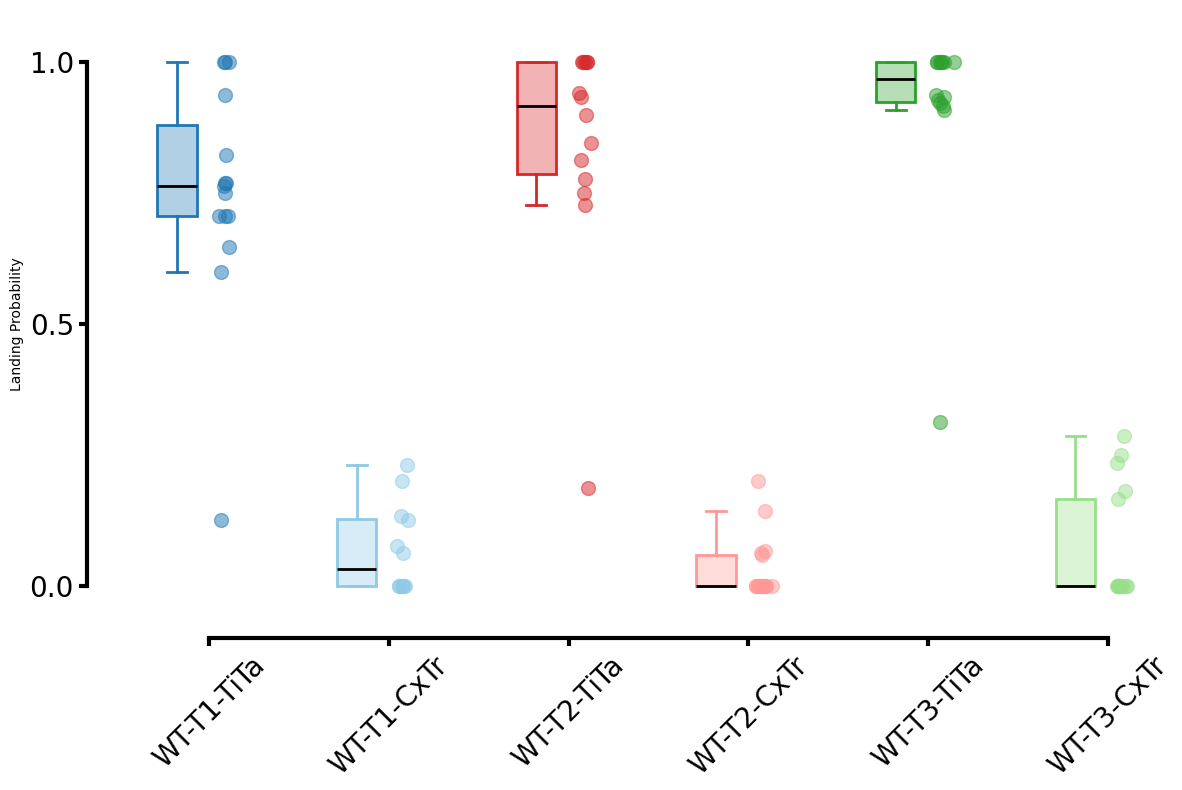

In [11]:
out = output_folder("Figure2A")
pdf = out / "Figure2A_WT_landing_probability.pdf"

plotter.plot_LP_summary_from_groups(
    groups=wt_groups_ordered,
    file_name=str(pdf.with_suffix("")),
    colors=wt_group_colors,
    markers=wt_group_markers,
)

stat_rows = []
for group_a, group_b in wt_planned_group_pairs:
    prefix = out / f"Figure2A_{group_a.group_name}_vs_{group_b.group_name}_LP"
    result, _ = stats_runner.compare_lp_unpaired(
        group_a=group_a,
        group_b=group_b,
        out_prefix=str(prefix),
        n_perm=N_PERM,
        pairwise_comparison_count=len(wt_planned_group_pairs),
    )
    stat_rows.append(result)
pd.concat(stat_rows, ignore_index=True).to_csv(
    out / "Figure2A_WT_landing_probability_pairwise_stats.csv",
    index=False,
)

## Figure 2A - NoContact landing probability

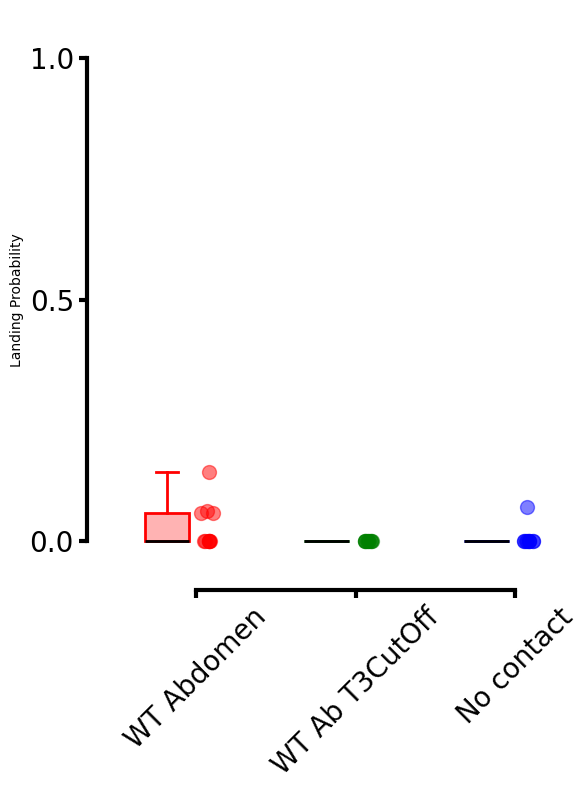

,comparison,test,metric,group_a,group_b,N_a,mean_a,std_a,N_b,mean_b,std_b,n_a,n_b,mean_diff_b_minus_a,p_value,n_perm,n_pairwise_comparison
0,WT Abdomen vs WT Ab T3CutOff,ablation_landing_probability_unpaired_permutation,landing_probability,WT Abdomen,WT Ab T3CutOff,11,0.029364,0.046637,9,0.000000,0.000000,NaN,NaN,-0.029364,0.073046,20000,3
1,WT Abdomen vs No contact,ablation_landing_probability_unpaired_permutation,landing_probability,WT Abdomen,No contact,11,0.029364,0.046637,10,0.007143,0.022588,NaN,NaN,-0.022221,0.244938,20000,3
2,WT Ab T3CutOff vs No contact,ablation_landing_probability_unpaired_permutation,landing_probability,WT Ab T3CutOff,No contact,9,0.000000,0.000000,10,0.007143,0.022588,NaN,NaN,0.007143,1.000000,20000,3


In [13]:
no_contact_data = load_lp_data(no_contact_specs)
with working_directory(output_folder("Figure2A")):
    pl.plot_LP_summary(
        plotter,
        data_to_plot=no_contact_data,
        file_name="Figure2A_NoContact",
        colors=["red", "green", "blue"],
        markers=["o"] * len(no_contact_data),
        box_width=0.28,
        box_softness=0.70,
    )
    no_contact_stats = run_lp_permutation_stats(
        no_contact_data,
        file_name="Figure2A_NoContact",
        n_perm=N_PERM,
    )
display(no_contact_stats)
show_pdf(panel_prefix("2A", "NoContact").with_suffix(".pdf"))

## Figure 2B - WT landing latency

In [15]:
out = output_folder("Figure2B")
pdf = out / "Figure2B_WT_landing_latency-LL-KMC-flipped.pdf"

plotter.plot_KM_curve_from_groups(
    groups=wt_groups_ordered,
    file_name=str(out / "Figure2B_WT_landing_latency"),
    colors=wt_group_colors,
    linestyles=wt_group_linestyles,
    markers={group.group_name: None for group in wt_groups_ordered},
)

stat_rows = []
for group_a, group_b in wt_planned_group_pairs:
    prefix = out / f"Figure2B_{group_a.group_name}_vs_{group_b.group_name}_LL"
    result, _ = stats_runner.analyze_landing_unpaired(
        group_a=group_a,
        group_b=group_b,
        out_prefix=str(prefix),
        n_perm=N_PERM,
        pairwise_comparison_count=len(wt_planned_group_pairs),
    )
    stat_rows.append(result)
pd.concat(stat_rows, ignore_index=True).to_csv(
    out / "Figure2B_WT_landing_latency_pairwise_fly_RMST_stats.csv",
    index=False,
)
show_pdf(pdf)

## Figure 2C - WT angle traces

In [17]:
out = output_folder("Figure2C")
pdf = out / "Figure2C_WT_CT_FT_angle_traces.pdf"
plotter.plot_wt_contact_group_angle_traces(
    groups_by_column={"TiTa": wt_tita_groups},
    file_name=str(pdf.with_suffix("")),
    contact_leg_map={"T1": "R-f", "T2": "R-m", "T3": "R-h"},
    contact_colors={"T1": "#1f77b4", "T2": "#d62728", "T3": "#2ca02c"},
    start_s=-0.1,
    end_s=0.1,
    target_fps=250,
    trial_types=("Landing", "Flying"),
    show_sem=True,
    **WT_ANGLE_QC_KWARGS,
)
show_pdf(pdf)

## Figures 2F and 2I - Mean projected trajectories and radial angles by leg

In [19]:
# Retain the complete trajectory/displacement plot and the leg-grouped angle
# plot; save the radial tests with Figure 2I.
with TemporaryDirectory(prefix="figure2_TT_") as temporary:
    prefix = Path(temporary) / "TT"
    result = plotter.plot_TT_MOC_to_SLC_endpoint_projected_combined(
      group_info={
          "T1": groups["WT_T1_TTa"],
          "T2": groups["WT_T2_TTa"],
          "T3": groups["WT_T3_TTa"],
      },
      sc_csv_paths={
          "T1": SC_DATA_DIR / "WT-T1-TiTa_LegContact.csv",
          "T2": SC_DATA_DIR / "WT-T2-TiTa_LegContact.csv",
          "T3": SC_DATA_DIR / "WT-T3-TiTa_LegContact.csv",
      },
      tau=0.71,
      file_name=str(prefix),
      normalized_average_points=200,
      trial_color="0.55",
      trial_linewidth=0.25,
      trial_alpha=0.7,
      fly_linewidth=1.4,
      fly_alpha=0.95,
      radial_circle_diameter=3.0,
      n_perm=N_PERM,
      **WT_TT_QC_KWARGS,
      save_csv=True,
    )
    # Copy the original complete PDF, preserving both columns, circles, and legend.
    shutil.copy2(prefix.with_suffix(".pdf"), panel_prefix("2F", "mean_projected_trajectories").with_suffix(".pdf"))
    export_generated(prefix, "2F", "TT", routes={
        "_radial_angle_by_leg_stripplot.pdf": "2I",
        "_fly_average_radial_angles.csv": "2I",
        "_radial_direction_stats.csv": "2I",
        "_radial_displacement_data.csv": "2I",
        "_fly_average_radial_displacement.csv": "2I",
    }, pdfs={"_radial_angle_by_leg_stripplot.pdf"})
show_pdf(panel_prefix("2F", "mean_projected_trajectories").with_suffix(".pdf"), height=900)
show_pdf(str(panel_prefix("2I", "TT")) + "_radial_angle_by_leg_stripplot.pdf")

## Figure 2G - Secondary-contact cumulative probability

In [21]:
out = output_folder("Figure2G")
generated_pdfs = []
for contact_group, group_info in wt_tita_groups.items():
    prefix = out / f"Figure2G_WT_{contact_group}_TiTa_manual_SC_inverted_KM"
    plotter.plot_manual_sc_inverted_km_from_csv(
        group_info=group_info,
        sc_csv_path=wt_tita_sc_paths[contact_group],
        legs=wt_tita_manual_sc_legs[contact_group],
        threshold=0.71,
        file_name=str(prefix),
    )
    generated_pdfs.extend([
        Path(f"{prefix}_all_trials.pdf"),
    ])

plotter.compare_manual_sc_rmst_across_contact_groups(
    group_infos=wt_tita_groups,
    sc_csv_paths=wt_tita_sc_paths,
    contact_groups=("T1", "T2", "T3"),
    legs=wt_tita_manual_sc_legs,
    threshold=0.71,
    n_perm=N_PERM,
    file_name=str(out / "Figure2G_WT_TiTa_manual_SC_RMST"),
)

for pdf in generated_pdfs:
    show_pdf(pdf, height=650)

## Figure 2H - First-secondary-contact probability

In [23]:
out = output_folder("Figure2H")
pdf = out / "Figure2H_WT_TiTa_flywise_first_contact_participation_probability.pdf"
plotter.plot_flywise_first_sc_probability_by_contact_group(
    group_infos=wt_tita_groups,
    sc_csv_paths=wt_tita_sc_paths,
    contact_groups=("T1", "T2", "T3"),
    legs=("L-f", "L-m", "L-h"),
    threshold=0.71,
    n_perm=N_PERM,
    file_name=str(pdf.with_suffix("")),
)
show_pdf(pdf)

## Figure 2J - Secondary-contact count probability histogram

In [25]:
# Export the histogram and its count-comparison statistics, excluding the scatter PDF.
with TemporaryDirectory(prefix="figure2J_") as temporary:
    prefix = Path(temporary) / "SC_count"
    plotter.plot_valid_sc_count_vs_landing_latency(
        group_info={
            "T1": groups["WT_T1_TTa"],
            "T2": groups["WT_T2_TTa"],
            "T3": groups["WT_T3_TTa"],
        },
        sc_csv_path=wt_tita_sc_paths,
        file_name=str(prefix),
        legs=("L-f", "L-m", "L-h", "R-f", "R-m", "R-h"),
        threshold=0.71,
        trial_types=("Landing", "Flying"),
        n_perm=N_PERM,
    )
    export_generated(prefix, "2J", "SC_count", pdfs={"_sc_count_distribution.pdf"})
show_pdf(str(panel_prefix("2J", "SC_count")) + "_sc_count_distribution.pdf")

C:\Users\wayne\OneDrive\Desktop\AnalysisAndFigures\plot_secondary_contact.py:988: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  prob_ax.legend(frameon=False, title="Outcome", loc="best")


## Figure 2K - Ablation landing probability

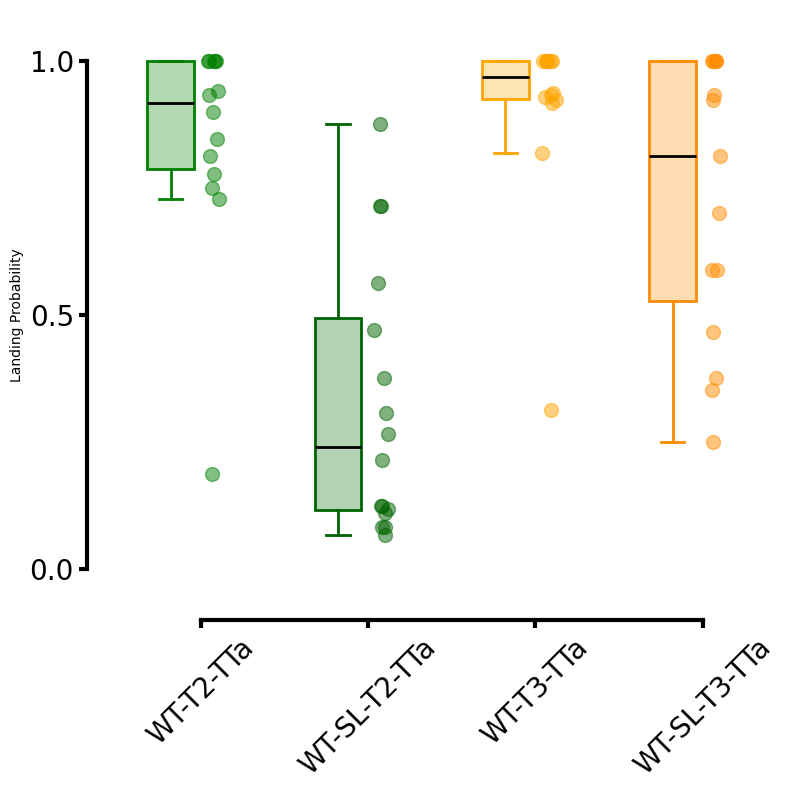

,comparison,test,metric,group_a,group_b,N_a,mean_a,std_a,N_b,mean_b,std_b,n_a,n_b,mean_diff_b_minus_a,p_value,n_perm,n_pairwise_comparison
0,WT-T2-TTa vs WT-SL-T2-TTa,ablation_landing_probability_unpaired_permutation,landing_probability,WT-T2-TTa,WT-SL-T2-TTa,14,0.848265,0.214981,16,0.325775,0.265069,NaN,NaN,-0.522491,0.000050,20000,6
1,WT-T2-TTa vs WT-T3-TTa,ablation_landing_probability_unpaired_permutation,landing_probability,WT-T2-TTa,WT-T3-TTa,14,0.848265,0.214981,14,0.912131,0.180583,NaN,NaN,0.063865,0.435378,20000,6
2,WT-T2-TTa vs WT-SL-T3-TTa,ablation_landing_probability_unpaired_permutation,landing_probability,WT-T2-TTa,WT-SL-T3-TTa,14,0.848265,0.214981,15,0.732666,0.275014,NaN,NaN,-0.115599,0.222789,20000,6
3,WT-SL-T2-TTa vs WT-T3-TTa,ablation_landing_probability_unpaired_permutation,landing_probability,WT-SL-T2-TTa,WT-T3-TTa,16,0.325775,0.265069,14,0.912131,0.180583,NaN,NaN,0.586356,0.000050,20000,6
4,WT-SL-T2-TTa vs WT-SL-T3-TTa,ablation_landing_probability_unpaired_permutation,landing_probability,WT-SL-T2-TTa,WT-SL-T3-TTa,16,0.325775,0.265069,15,0.732666,0.275014,NaN,NaN,0.406891,0.000600,20000,6
5,WT-T3-TTa vs WT-SL-T3-TTa,ablation_landing_probability_unpaired_permutation,landing_probability,WT-T3-TTa,WT-SL-T3-TTa,14,0.912131,0.180583,15,0.732666,0.275014,NaN,NaN,-0.179465,0.050097,20000,6


In [27]:
ablation_data = load_lp_data(ablation_specs)
with working_directory(output_folder("Figure2K")):
    pl.plot_LP_summary(
        plotter,
        data_to_plot=ablation_data,
        file_name="Figure2K_Ablation",
        colors=["green", "darkgreen", "orange", "darkorange"],
        markers=["o"] * len(ablation_data),
        box_width=0.28,
        box_softness=0.70,
    )
    ablation_stats = run_lp_permutation_stats(
        ablation_data,
        file_name="Figure2K_Ablation",
        n_perm=N_PERM,
    )
display(ablation_stats)
show_pdf(panel_prefix("2K", "Ablation").with_suffix(".pdf"))